<a href="https://colab.research.google.com/github/Animesh90-me/Practice-Workflow-for-SEM-Image-Analysis-and-PINN-Based-Salting-Out-Prediction/blob/main/01_sem_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import os

zip_path = "FIBER_BIG.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Files after unzip:")
print(os.listdir("/content/"))

Files after unzip:
['.config', 'MWCNT_008.tif', 'MWCNT_003.tif', 'FIBER_small_003.tif', 'MWCNT_009.tif', 'selfhealing_007.tif', 'Nacl_001.tif', 'MWCNT_005.tif', 'selfhealing_003.tif', 'MWCNT_001.tif', 'FIBER_BIG_003.tif', 'FIBER_small.tif', 'Nacl_002.tif', 'MWCNT.tif', 'selfhealing_006.tif', 'selfhealing_001.tif', 'selfhealing_004.tif', 'MWCNT_006.tif', 'MWCNT_002.tif', 'FIBER_small_001.tif', 'selfhealing_005.tif', 'MWCNT_004.tif', 'FIBER_BIG.zip', 'FIBER_BIG_002.tif', 'MWCNT_007.tif', 'Nacl.tif', 'FIBER_short.tif', 'selfhealing_002.tif', 'FIBER_BIG.tif', 'FIBER_BIG_001.tif', 'selfhealing.tif', 'FIBER_small_002.tif', 'FIBER_short_001.tif', 'sample_data']


In [3]:
print(os.listdir("/content/"))

['.config', 'MWCNT_008.tif', 'MWCNT_003.tif', 'FIBER_small_003.tif', 'MWCNT_009.tif', 'selfhealing_007.tif', 'Nacl_001.tif', 'MWCNT_005.tif', 'selfhealing_003.tif', 'MWCNT_001.tif', 'FIBER_BIG_003.tif', 'FIBER_small.tif', 'Nacl_002.tif', 'MWCNT.tif', 'selfhealing_006.tif', 'selfhealing_001.tif', 'selfhealing_004.tif', 'MWCNT_006.tif', 'MWCNT_002.tif', 'FIBER_small_001.tif', 'selfhealing_005.tif', 'MWCNT_004.tif', 'FIBER_BIG.zip', 'FIBER_BIG_002.tif', 'MWCNT_007.tif', 'Nacl.tif', 'FIBER_short.tif', 'selfhealing_002.tif', 'FIBER_BIG.tif', 'FIBER_BIG_001.tif', 'selfhealing.tif', 'FIBER_small_002.tif', 'FIBER_short_001.tif', 'sample_data']


In [7]:
import os
import shutil

base_path = "/content/FIBER_BIG"

os.makedirs(base_path, exist_ok=True)

classes = ["selfhealing", "Nacl", "MWCNT"]

for cls in classes:
    os.makedirs(os.path.join(base_path, cls), exist_ok=True)

for file in os.listdir("/content/"):
    if file.lower().endswith((".tif", ".tiff", ".jpg", ".jpeg", ".png")):

        if file.startswith("selfhealing"):
            shutil.move("/content/" + file, os.path.join(base_path, "selfhealing", file))

        elif file.startswith("Nacl"):
            shutil.move("/content/" + file, os.path.join(base_path, "Nacl", file))

        elif file.startswith("MWCNT"):
            shutil.move("/content/" + file, os.path.join(base_path, "MWCNT", file))

print("Done organizing images.")
print(os.listdir(base_path))

Done organizing images.
['selfhealing', 'MWCNT', 'Nacl']


In [13]:
for folder in os.listdir("/content/FIBER_BIG"):
    folder_path = os.path.join("/content/FIBER_BIG", folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

selfhealing : 8 images
MWCNT : 10 images
Nacl : 3 images


In [14]:
dataset_path = "/content/FIBER_BIG"

In [15]:
import os
from PIL import Image

dataset_path = "/content/FIBER_BIG"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            tif_path = os.path.join(root, file)
            png_path = os.path.join(root, file.rsplit(".", 1)[0] + ".png")

            img = Image.open(tif_path)
            img = img.convert("RGB")
            img.save(png_path)

print("TIF images converted to PNG.")

TIF images converted to PNG.


In [16]:
import os

for folder in os.listdir("/content/FIBER_BIG"):
    folder_path = os.path.join("/content/FIBER_BIG", folder)
    if os.path.isdir(folder_path):
        print(folder, ":", os.listdir(folder_path)[:5])

selfhealing : ['selfhealing_005.png', 'selfhealing_007.tif', 'selfhealing.png', 'selfhealing_001.png', 'selfhealing_003.tif']
MWCNT : ['MWCNT_008.tif', 'MWCNT_003.tif', 'MWCNT_008.png', 'MWCNT_009.png', 'MWCNT_009.tif']
Nacl : ['Nacl_001.tif', 'Nacl_002.png', 'Nacl_002.tif', 'Nacl_001.png', 'Nacl.tif']


In [17]:
import tensorflow as tf

dataset_path = "/content/FIBER_BIG"

img_size = (224, 224)
batch_size = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 21 files belonging to 3 classes.
Using 17 files for training.
Found 21 files belonging to 3 classes.
Using 4 files for validation.
Classes: ['MWCNT', 'Nacl', 'selfhealing']


In [22]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

In [23]:
from tensorflow.keras import models, layers

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step - accuracy: 0.4706 - loss: 1.0991 - val_accuracy: 0.0000e+00 - val_loss: 1.1195
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 0.1765 - loss: 1.1058 - val_accuracy: 0.5000 - val_loss: 1.0835
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 602ms/step - accuracy: 0.4706 - loss: 1.0941 - val_accuracy: 0.5000 - val_loss: 1.0249
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 591ms/step - accuracy: 0.4706 - loss: 1.0534 - val_accuracy: 0.5000 - val_loss: 0.9464
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4706 - loss: 1.0499 - val_accuracy: 0.5000 - val_loss: 0.8918
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 498ms/step - accuracy: 0.4706 - loss: 1.0662 - val_accuracy: 0.5000 - val_loss: 0.8603
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 480ms/step - accuracy: 0.4706 - loss: 1.1198 - val_accuracy: 0.5000 - val_loss: 0.8489
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.4706 - loss: 1.0176 - val_accuracy: 0.5000 - val_loss

In [27]:
from google.colab import files

uploaded = files.upload()

Saving FIBER_BIG.tif to FIBER_BIG (1).tif
Saving FIBER_BIG_001.tif to FIBER_BIG_001 (1).tif
Saving FIBER_BIG_002.tif to FIBER_BIG_002 (1).tif
Saving FIBER_BIG_003.tif to FIBER_BIG_003 (1).tif
Saving FIBER_short.tif to FIBER_short (1).tif
Saving FIBER_short_001.tif to FIBER_short_001 (1).tif
Saving FIBER_small.tif to FIBER_small (1).tif
Saving FIBER_small_001.tif to FIBER_small_001 (1).tif
Saving FIBER_small_002.tif to FIBER_small_002 (1).tif
Saving FIBER_small_003.tif to FIBER_small_003 (1).tif
Saving MWCNT.tif to MWCNT.tif
Saving MWCNT_001.tif to MWCNT_001.tif
Saving MWCNT_002.tif to MWCNT_002.tif
Saving MWCNT_006.tif to MWCNT_006.tif
Saving MWCNT_007.tif to MWCNT_007.tif
Saving MWCNT_008.tif to MWCNT_008.tif
Saving MWCNT_009.tif to MWCNT_009.tif
Saving selfhealing.tif to selfhealing.tif
Saving selfhealing_001.tif to selfhealing_001.tif
Saving selfhealing_002.tif to selfhealing_002.tif
Saving selfhealing_003.tif to selfhealing_003.tif
Saving selfhealing_004.tif to selfhealing_004.tif


In [28]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Get uploaded image filenames
uploaded_files = list(uploaded.keys())

print("Uploaded files:")
print(uploaded_files)

Uploaded files:
['FIBER_BIG (1).tif', 'FIBER_BIG_001 (1).tif', 'FIBER_BIG_002 (1).tif', 'FIBER_BIG_003 (1).tif', 'FIBER_short (1).tif', 'FIBER_short_001 (1).tif', 'FIBER_small (1).tif', 'FIBER_small_001 (1).tif', 'FIBER_small_002 (1).tif', 'FIBER_small_003 (1).tif', 'MWCNT.tif', 'MWCNT_001.tif', 'MWCNT_002.tif', 'MWCNT_006.tif', 'MWCNT_007.tif', 'MWCNT_008.tif', 'MWCNT_009.tif', 'selfhealing.tif', 'selfhealing_001.tif', 'selfhealing_002.tif', 'selfhealing_003.tif', 'selfhealing_004.tif']


In [29]:
for image_name in uploaded_files:
    if image_name.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):

        # Open image
        img = Image.open(image_name)
        img = img.convert("RGB")
        img = img.resize((224, 224))

        # Convert to array
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        print("Image:", image_name)
        print("Prediction:", predicted_class)
        print("Confidence:", round(confidence, 2), "%")
        print("-------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Image: FIBER_BIG (1).tif
Prediction: MWCNT
Confidence: 92.24 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Image: FIBER_BIG_001 (1).tif
Prediction: MWCNT
Confidence: 92.64 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Image: FIBER_BIG_002 (1).tif
Prediction: MWCNT
Confidence: 92.23 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Image: FIBER_BIG_003 (1).tif
Prediction: MWCNT
Confidence: 93.0 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Image: FIBER_short (1).tif
Prediction: MWCNT
Confidence: 88.85 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Image: FIBER_short_001 (1).tif
Prediction: MWCNT
Confidence: 90.15 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Image: FIBER_small (1).tif
Prediction: MWCNT
Confidence: 87.91 %
-------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Image: FIBER_small_001 (1).tif
Prediction: MWCNT
Co

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


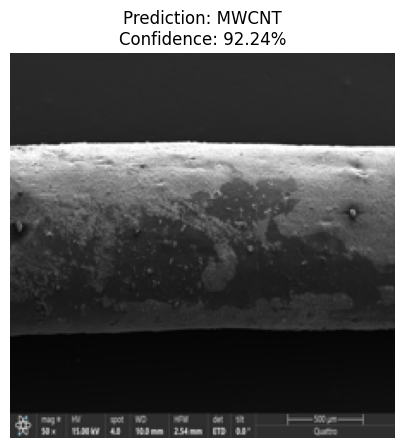

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


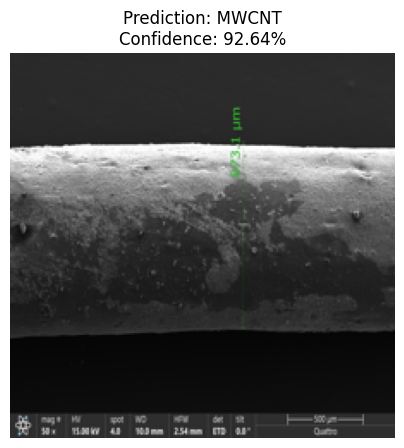

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


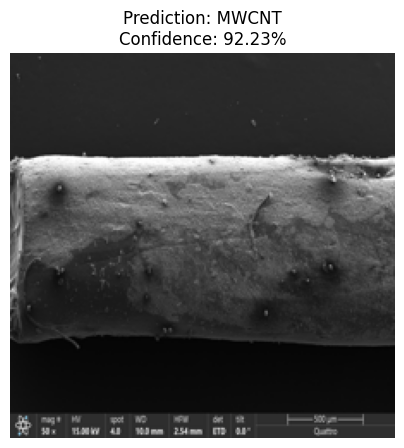

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


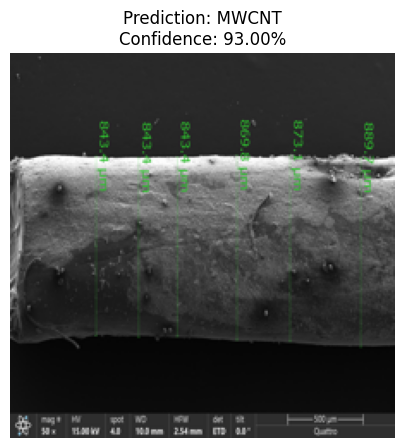

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


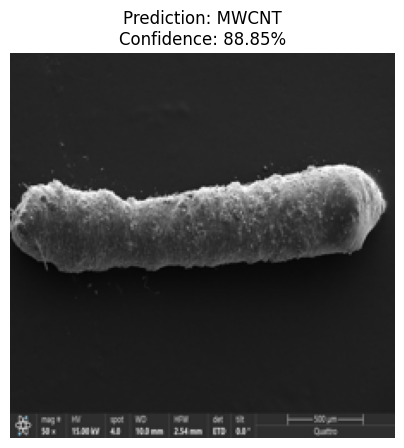

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


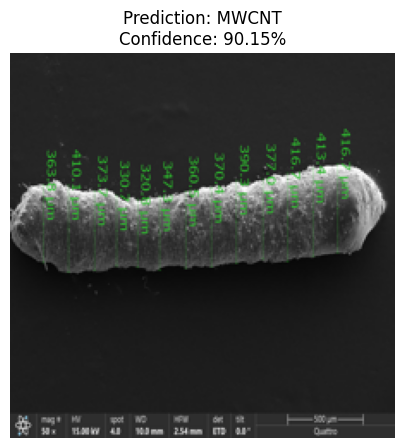

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


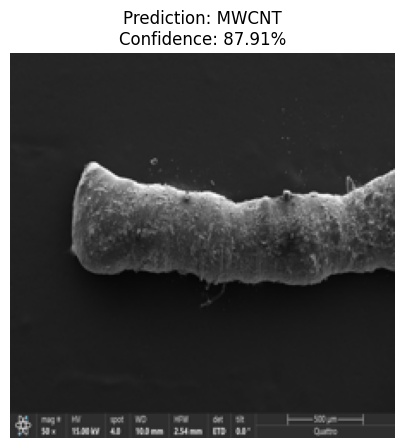

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


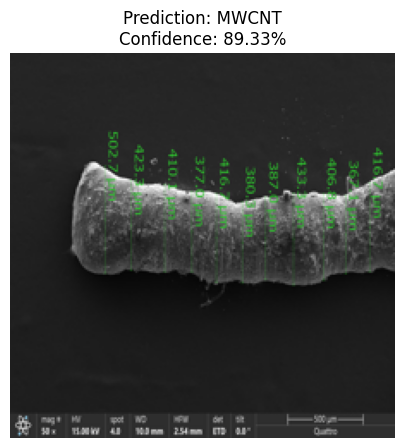

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


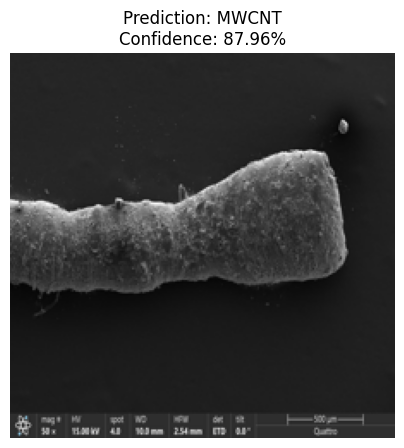

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


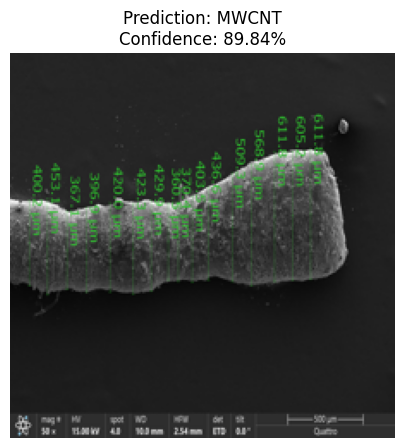

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


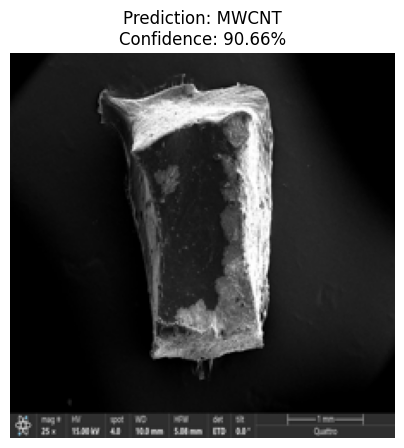

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


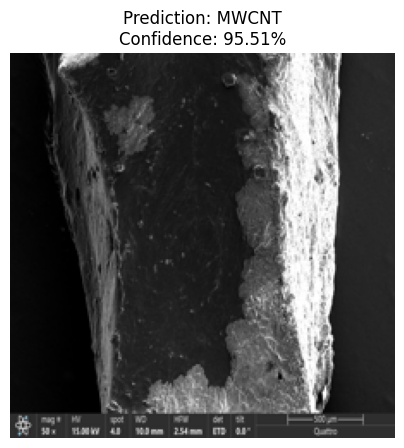

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


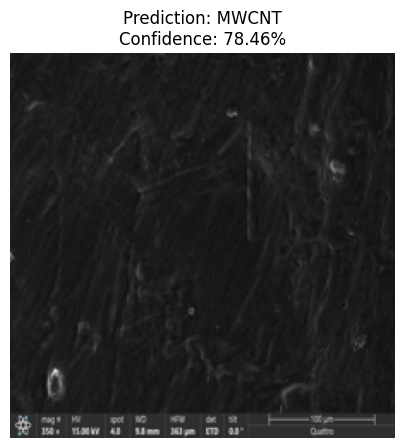

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


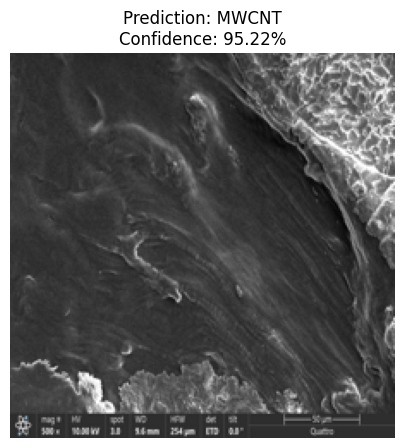

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


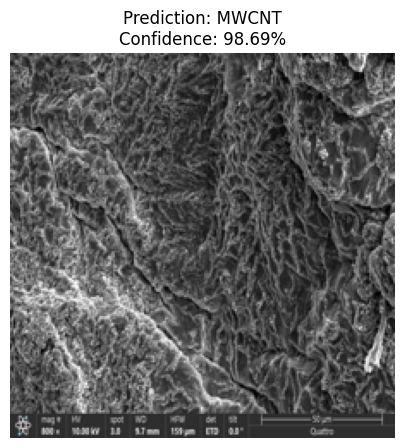

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


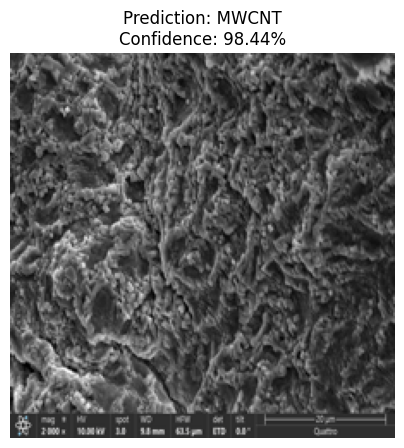

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


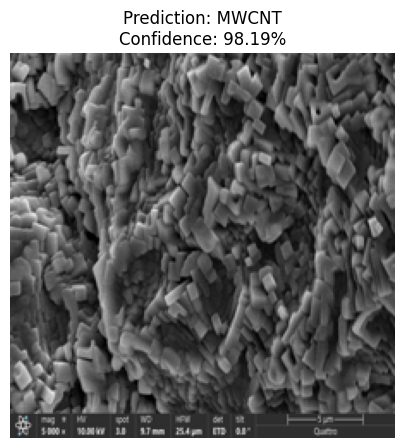

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


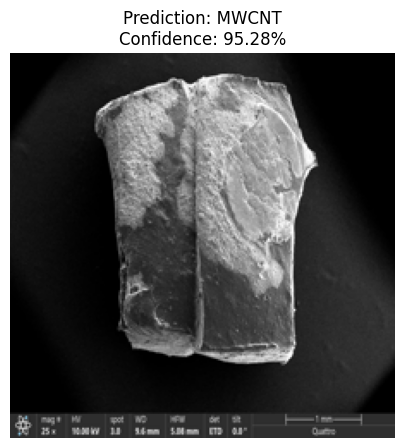

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


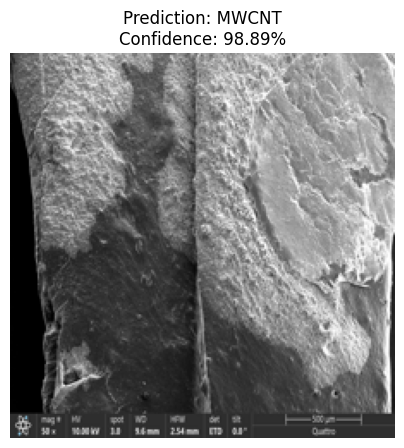

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


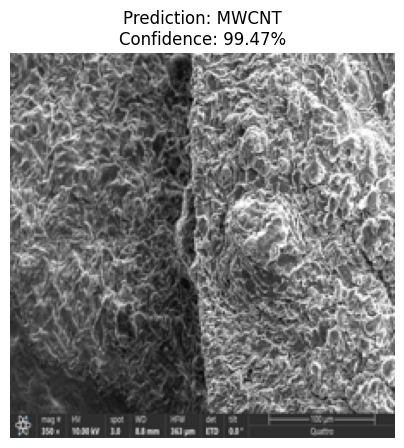

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


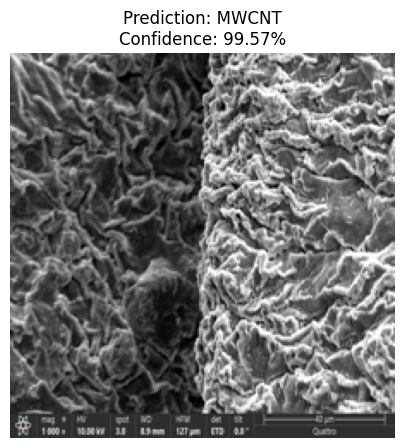

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


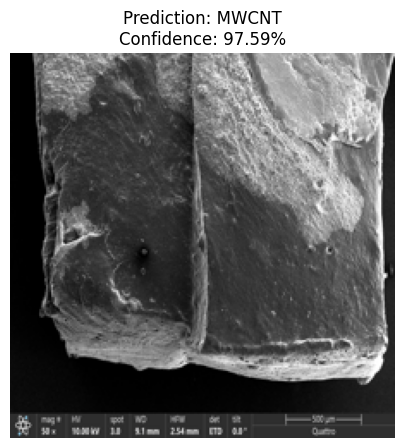

In [30]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

uploaded_files = list(uploaded.keys())

for image_name in uploaded_files:
    if image_name.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):

        # Open image
        img = Image.open(image_name)
        img = img.convert("RGB")
        img_resized = img.resize((224, 224))

        # Prepare image for model
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Show output image
        plt.figure(figsize=(5, 5))
        plt.imshow(img_resized)
        plt.axis("off")
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


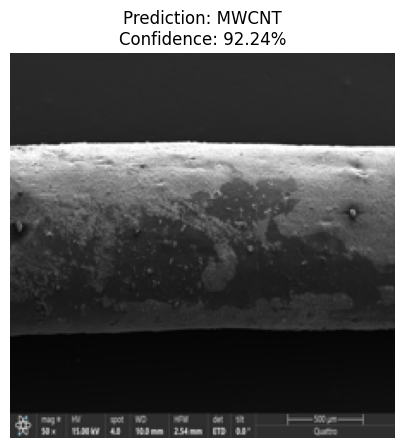

Saved: /content/predicted_output/FIBER_BIG (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


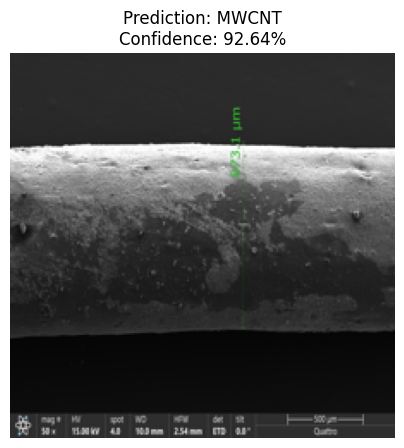

Saved: /content/predicted_output/FIBER_BIG_001 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


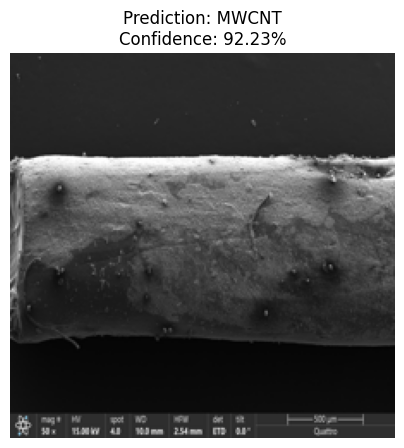

Saved: /content/predicted_output/FIBER_BIG_002 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


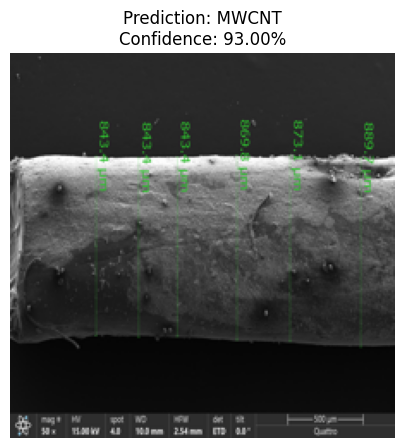

Saved: /content/predicted_output/FIBER_BIG_003 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


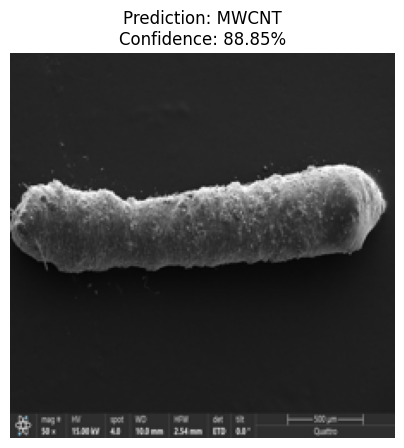

Saved: /content/predicted_output/FIBER_short (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


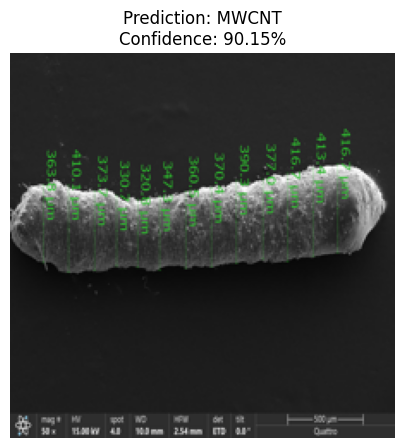

Saved: /content/predicted_output/FIBER_short_001 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


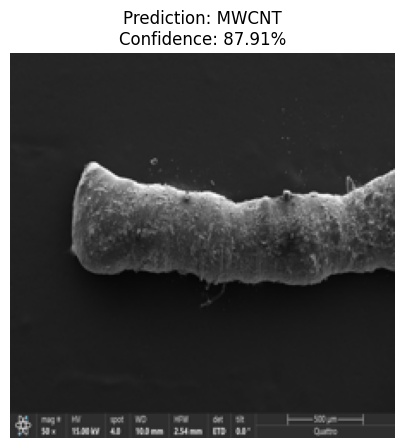

Saved: /content/predicted_output/FIBER_small (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


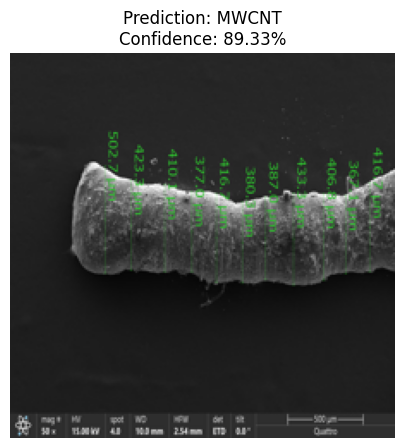

Saved: /content/predicted_output/FIBER_small_001 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


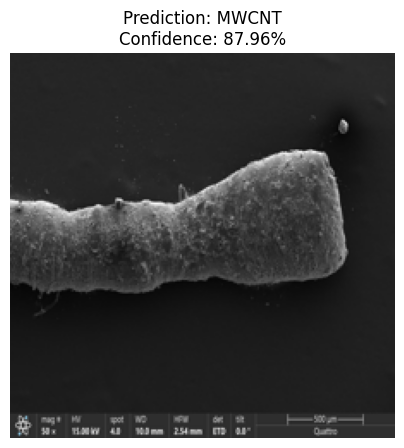

Saved: /content/predicted_output/FIBER_small_002 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


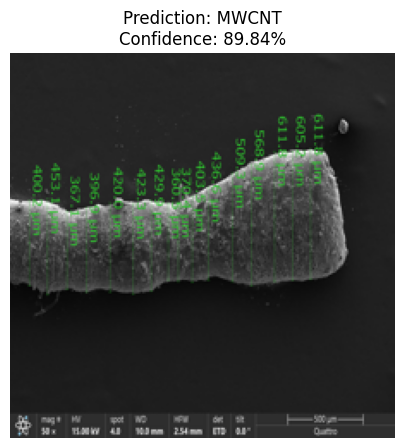

Saved: /content/predicted_output/FIBER_small_003 (1)_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


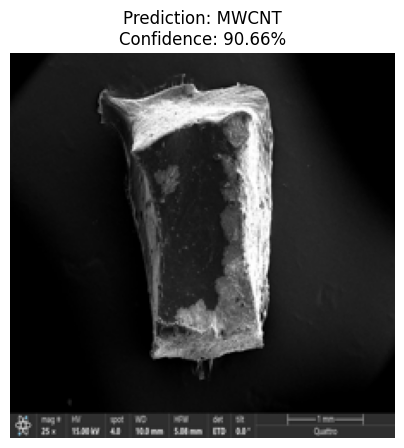

Saved: /content/predicted_output/MWCNT_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


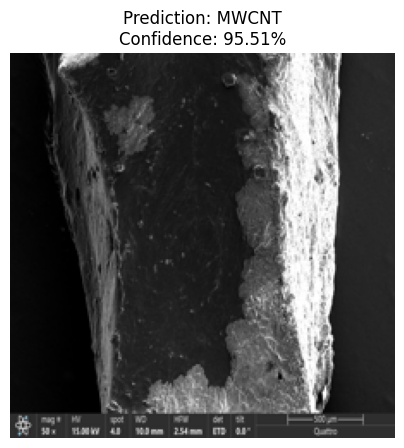

Saved: /content/predicted_output/MWCNT_001_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


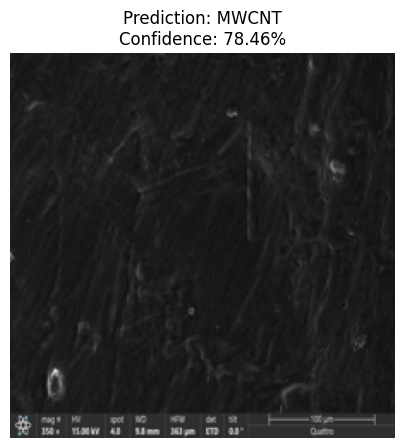

Saved: /content/predicted_output/MWCNT_002_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


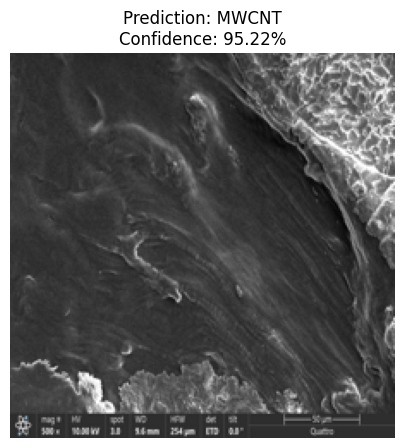

Saved: /content/predicted_output/MWCNT_006_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


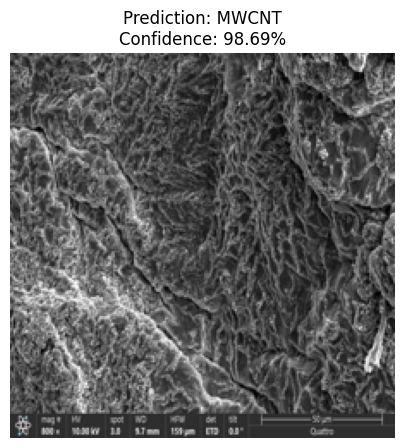

Saved: /content/predicted_output/MWCNT_007_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


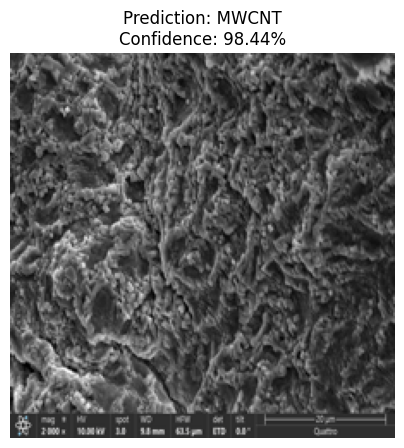

Saved: /content/predicted_output/MWCNT_008_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


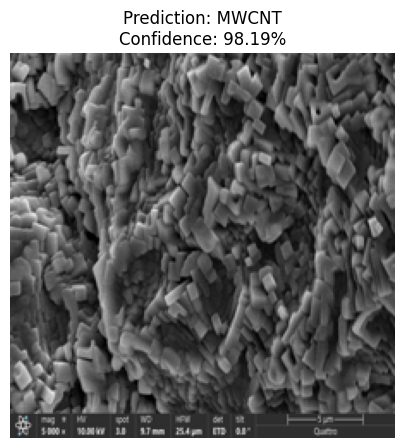

Saved: /content/predicted_output/MWCNT_009_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


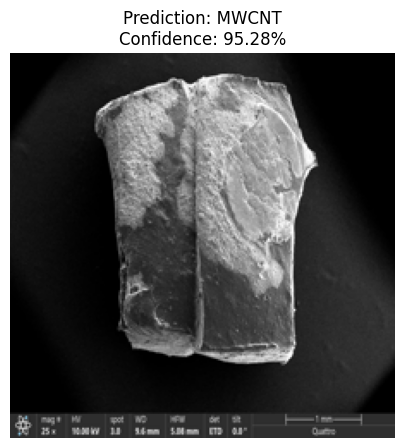

Saved: /content/predicted_output/selfhealing_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


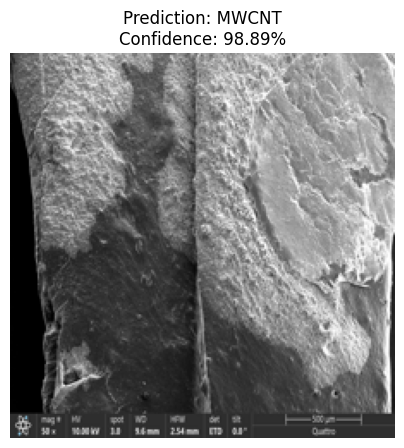

Saved: /content/predicted_output/selfhealing_001_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


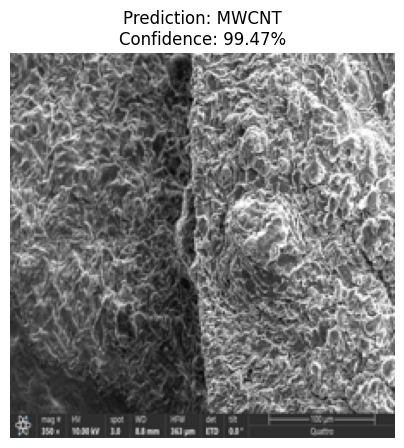

Saved: /content/predicted_output/selfhealing_002_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


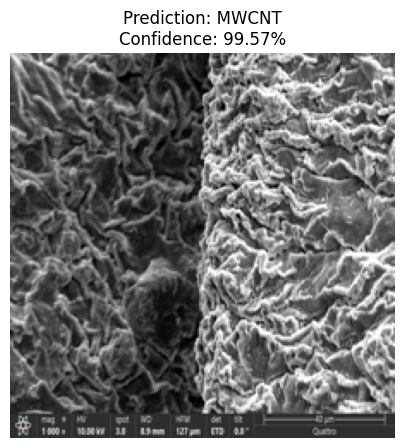

Saved: /content/predicted_output/selfhealing_003_prediction.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


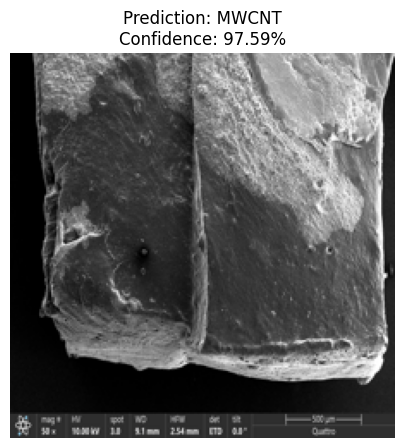

Saved: /content/predicted_output/selfhealing_004_prediction.png


In [31]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

output_folder = "/content/predicted_output"
os.makedirs(output_folder, exist_ok=True)

uploaded_files = list(uploaded.keys())

for image_name in uploaded_files:
    if image_name.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):

        img = Image.open(image_name)
        img = img.convert("RGB")
        img_resized = img.resize((224, 224))

        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)
        predicted_class = class_names[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        plt.figure(figsize=(5, 5))
        plt.imshow(img_resized)
        plt.axis("off")
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")

        save_name = image_name.rsplit(".", 1)[0] + "_prediction.png"
        save_path = os.path.join(output_folder, save_name)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.show()

        print("Saved:", save_path)

In [32]:
from google.colab import files
uploaded = files.upload()

Saving Nacl_002.tif to Nacl_002.tif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


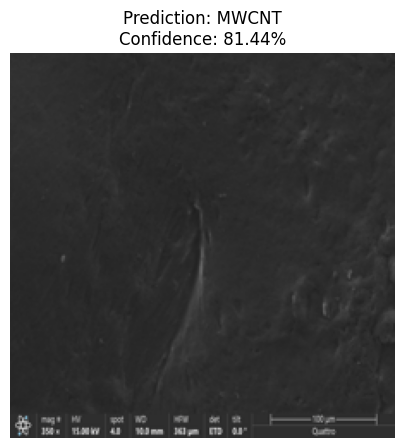

Uploaded image: Nacl_002.tif
Prediction: MWCNT
Confidence: 81.44 %


In [33]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Get the uploaded image name
image_name = list(uploaded.keys())[0]

# Open image
img = Image.open(image_name)
img = img.convert("RGB")
img_resized = img.resize((224, 224))

# Prepare image for model
img_array = np.array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show result
plt.figure(figsize=(5, 5))
plt.imshow(img_resized)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Uploaded image:", image_name)
print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")